![arnold](forest.jpg)
# 🧠 Técnicas de Inteligencia Artificial (TIA)
## 📝 Taller 3: Diseño y Optimización de un MLP Profundo

---

### 👤 Información del Proyecto
*   **Materia:** Técnicas de Inteligencia Artificial
*   **Actividad:** Taller 3 - Reconocimiento con Perceptrón Multicapa (MLP)
*   **Dataset:** 🎭 [Olivetti Faces](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html)

---

### 🎯 Objetivo General
Diseñar, entrenar y optimizar un **Perceptrón Multicapa (MLP)** profundo, sin utilizar redes convolucionales (CNN), para identificar personas en un problema de clasificación multiclase utilizando el dataset de rostros Olivetti.

### 🚀 Tecnologías Utilizadas
*   ![Python](https://img.shields.io/badge/python-3670A0?style=for-the-badge&logo=python&logoColor=ffdd54)
*   ![Scikit-Learn](https://img.shields.io/badge/scikit--learn-%23F7931E.svg?style=for-the-badge&logo=scikit-learn&logoColor=white)
*   ![NumPy](https://img.shields.io/badge/numpy-%23013243.svg?style=for-the-badge&logo=numpy&logoColor=white)
*   ![Matplotlib](https://img.shields.io/badge/Matplotlib-%23ffffff.svg?style=for-the-badge&logo=Matplotlib&logoColor=black)

---

### 📂 Estructura de la Partición de Datos
Para garantizar la robustez del modelo, se ha aplicado la técnica de **Hold-out** con **Muestreo Estratificado**:
*   **60%** Entrenamiento 🏋️‍♂️
*   **20%** Validación ⚖️
*   **20%** Prueba 🏁

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

print("1. Cargando dataset de Olivetti Faces...")
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = faces.data, faces.target

print("2. Aplicando partición consistente con el Taller 3 (Hold-out 60/20/20)...")
semilla = 42

# Primera partición: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=semilla, stratify=y
)
# Segunda partición: 20% Val, 20% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=semilla, stratify=y_temp
)

print(f"Dimensiones - Entrenamiento: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Prueba: {X_test.shape[0]}")


1. Cargando dataset de Olivetti Faces...
2. Aplicando partición consistente con el Taller 3 (Hold-out 60/20/20)...
Dimensiones - Entrenamiento: 240 | Validación: 80 | Prueba: 80


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Entrenando Árbol de Decisión (DecisionTreeClassifier)...")

# Control de complejidad (Poda) para evitar sobreajuste
clf_tree = DecisionTreeClassifier(
    criterion="entropy",       # Medida de impureza usada en el ejemplo del profe
    max_depth=12,              # Limitamos la profundidad máxima
    min_samples_split=5,       # Mínimo de muestras para dividir un nodo
    random_state=semilla
)

# Entrenar el modelo con el conjunto de entrenamiento
clf_tree.fit(X_train, y_train)

# Métricas de Comparación (Evaluamos en Validación para contrastar con el MLP)
y_pred_val = clf_tree.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)

print(f"\n✅ Accuracy en el conjunto de VALIDACIÓN: {acc_val:.4f}")


Entrenando Árbol de Decisión (DecisionTreeClassifier)...

✅ Accuracy en el conjunto de VALIDACIÓN: 0.5000
-> Nota para el reporte: Contrasta este valor con el obtenido en tu mejor modelo MLP.


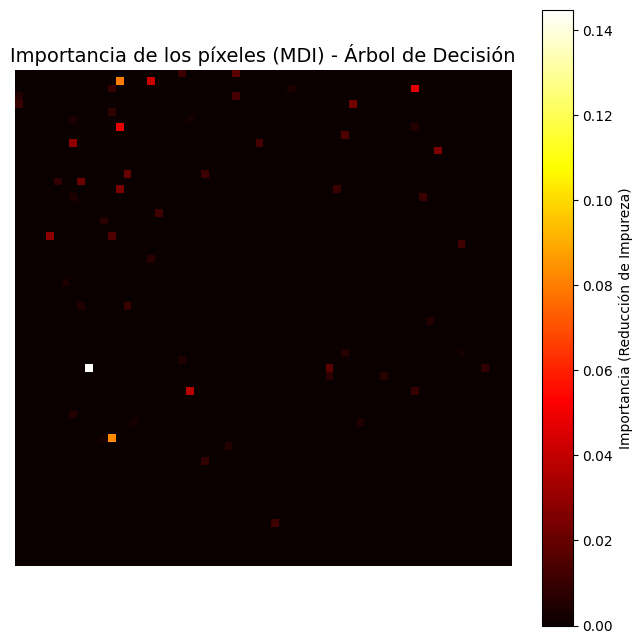

In [3]:
# Extraer la importancia de las características (basado en la reducción de impureza)
importances = clf_tree.feature_importances_

# Redimensionar el vector de 4096 a la forma original de la imagen (64x64)
importances_img = importances.reshape(64, 64)

# Visualización con mapa de calor (cmap='hot' como en el ejemplo del profesor)
plt.figure(figsize=(8, 8))
plt.imshow(importances_img, cmap="hot", interpolation="nearest")
plt.title("Importancia de los píxeles (MDI) - Árbol de Decisión", fontsize=14)
plt.colorbar(label="Importancia (Reducción de Impureza)")
plt.axis('off')
plt.show()


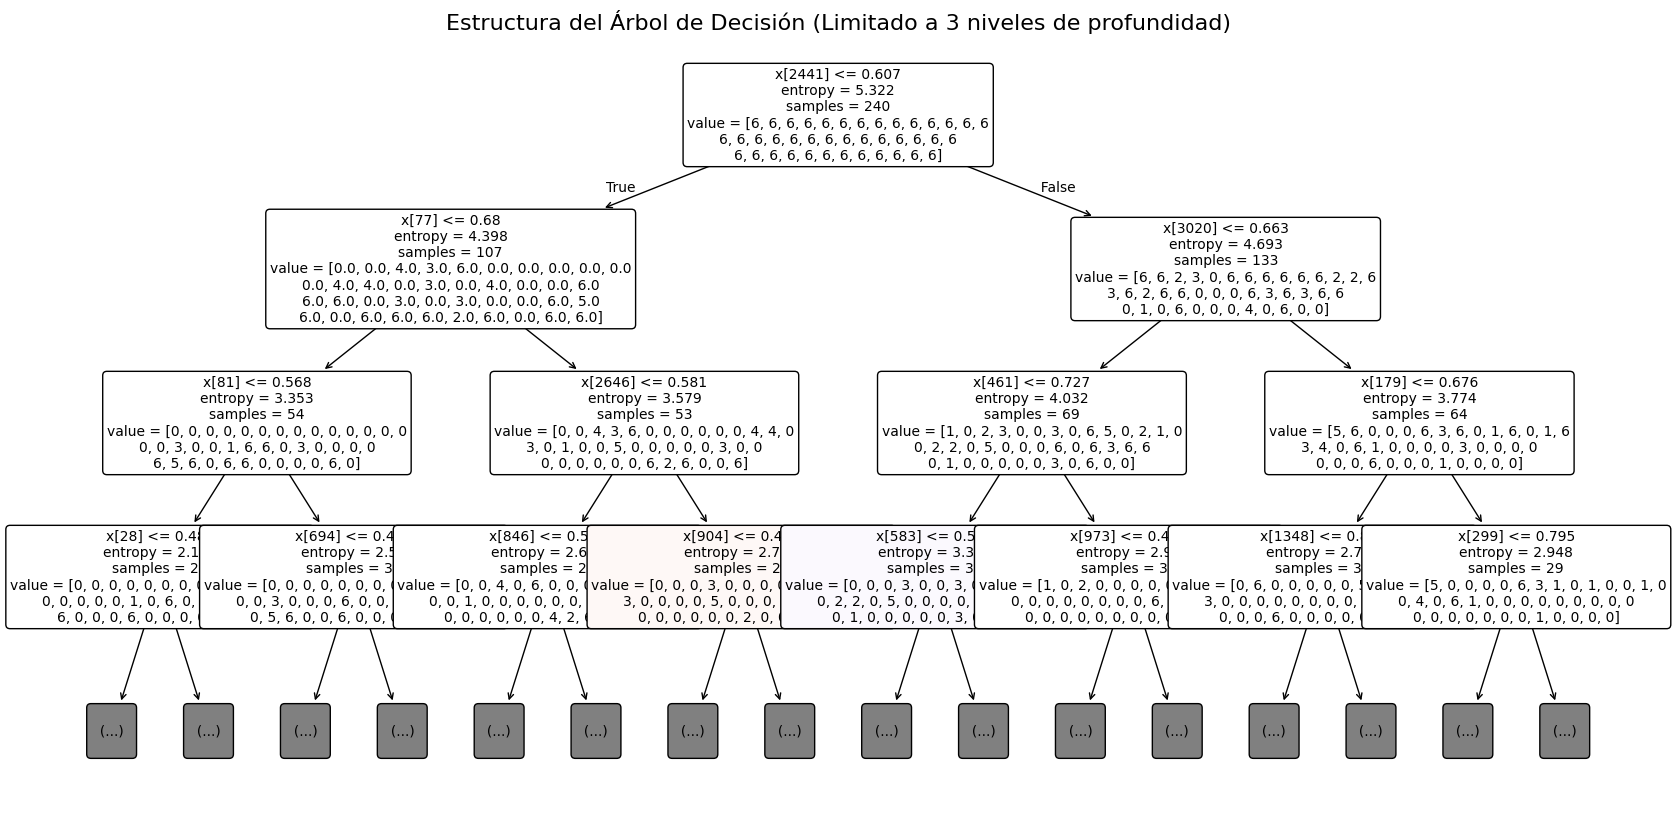

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

# Limitamos la visualización a los primeros 3 niveles (max_depth=3) en la gráfica
plot_tree(clf_tree,
          max_depth=3,
          filled=True, 
          rounded=True,
          fontsize=10)

plt.title("Estructura del Árbol de Decisión (Limitado a 3 niveles de profundidad)", fontsize=16)
plt.show()


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\2710863409.py:32: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


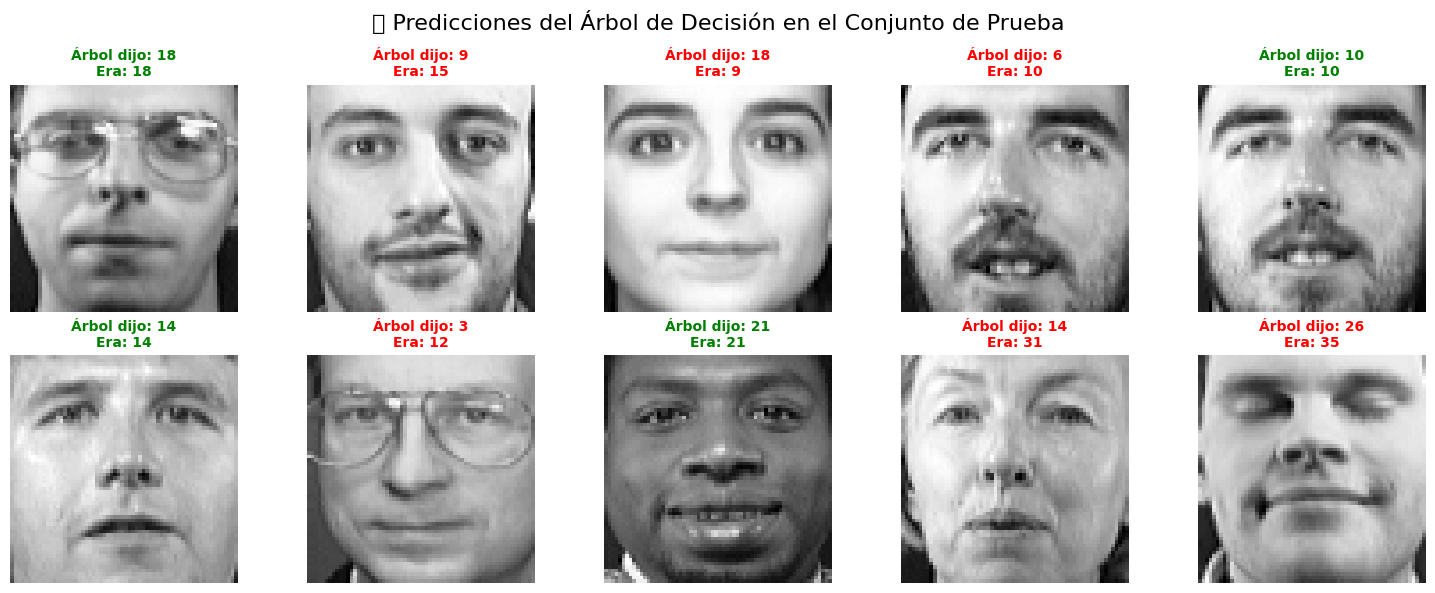

In [10]:
def visualizar_resultados_arbol(modelo, X_imagenes, y_reales, cantidad=10):
    """
    Muestra una cuadrícula de imágenes con las predicciones del Árbol de Decisión.
    """
    # 1. Obtener predicciones
    # El árbol usa los datos tal cual (X_imagenes ya son vectores de 4096)
    predicciones = modelo.predict(X_imagenes)
    
    # 2. Seleccionar índices aleatorios
    np.random.seed(42) # Para que las fotos sean consistentes en el reporte
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    # 3. Configurar la visualización
    plt.figure(figsize=(15, 6))
    plt.suptitle("🌲 Predicciones del Árbol de Decisión en el Conjunto de Prueba", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        # Redimensionar el vector de píxeles a 64x64
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        pred = predicciones[idx]
        real = y_reales[idx]
        
        # Color verde si acertó, rojo si falló
        color = 'green' if pred == real else 'red'
        plt.title(f"Árbol dijo: {pred}\nEra: {real}", color=color, fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización con los datos de PRUEBA (X_test, y_test)
visualizar_resultados_arbol(clf_tree, X_test, y_test, cantidad=10)


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo de Bosque Aleatorio
# Bootstrap: Crea sub-conjuntos aleatorios con reemplazo para entrenar cada árbol.
# Max_features: Selecciona solo una parte aleatoria de los píxeles en cada división,
#               lo que reduce la correlación entre árboles y mejora la generalización.
clf_rf = RandomForestClassifier(
    n_estimators=200,      # Número de árboles en el bosque
    max_depth=None,        # Dejamos que los árboles crezcan para capturar varianza
    max_features='sqrt',   # Selección aleatoria de atributos (sqrt de 4096)
    random_state=semilla,
    n_jobs=-1              # Usar todos los núcleos del procesador
)

# Entrenar el modelo
clf_rf.fit(X_train, y_train)

# Evaluación inicial en validación
y_pred_rf_val = clf_rf.predict(X_val)
acc_rf_val = accuracy_score(y_val, y_pred_rf_val)

print(f"✅ Accuracy del Random Forest en VALIDACIÓN: {acc_rf_val:.4f}")


✅ Accuracy del Random Forest en VALIDACIÓN: 0.9625


Probando diferentes tamaños de bosque...
 - Árboles:   1 | Accuracy: 0.4375
 - Árboles:  10 | Accuracy: 0.7750
 - Árboles:  30 | Accuracy: 0.8625
 - Árboles:  50 | Accuracy: 0.9375
 - Árboles: 100 | Accuracy: 0.9500
 - Árboles: 200 | Accuracy: 0.9625
 - Árboles: 300 | Accuracy: 0.9625


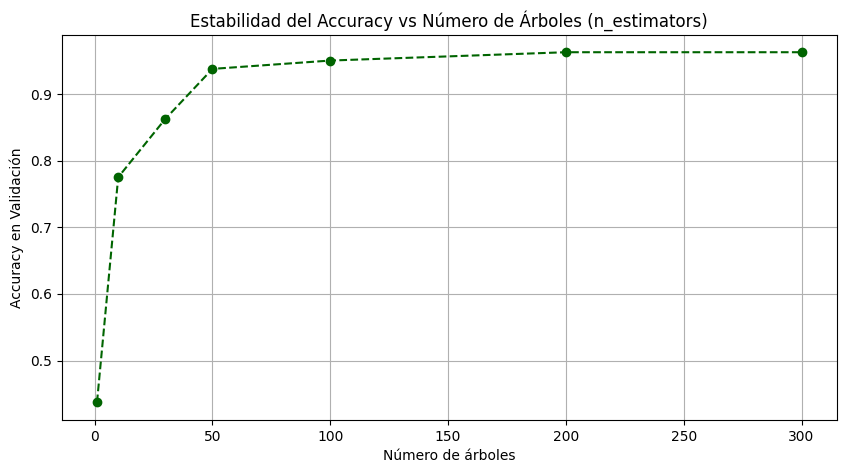

In [12]:
# Valores de n_estimators a probar (siguiendo la guía del profesor)
estimadores_lista = [1, 10, 30, 50, 100, 200, 300]
precisones_lista = []

print("Probando diferentes tamaños de bosque...")
for n in estimadores_lista:
    modelo_temp = RandomForestClassifier(n_estimators=n, random_state=semilla, n_jobs=-1)
    modelo_temp.fit(X_train, y_train)
    score = accuracy_score(y_val, modelo_temp.predict(X_val))
    precisones_lista.append(score)
    print(f" - Árboles: {n:3} | Accuracy: {score:.4f}")

# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(estimadores_lista, precisones_lista, marker='o', color='darkgreen', linestyle='--')
plt.title("Estabilidad del Accuracy vs Número de Árboles (n_estimators)")
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy en Validación")
plt.grid(True)
plt.show()


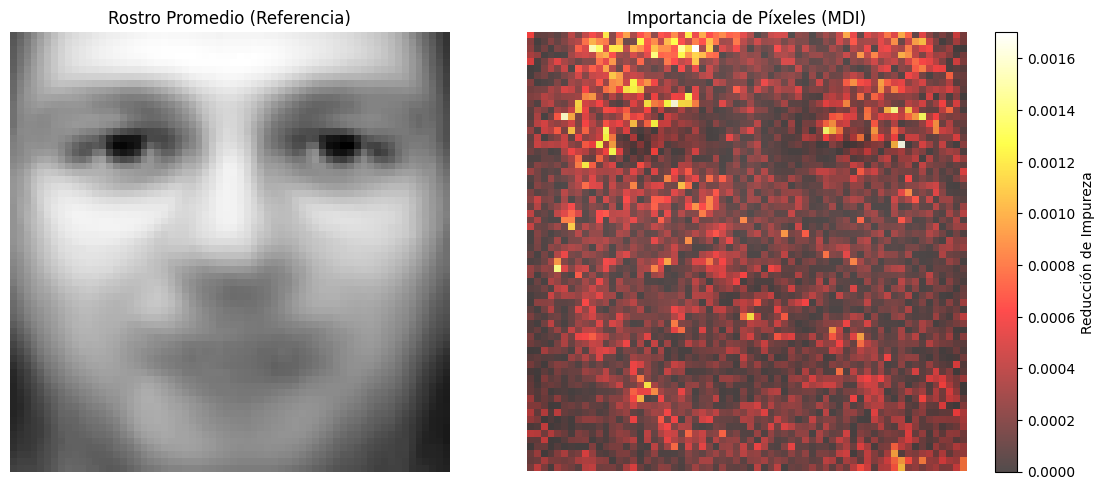

In [13]:
# 1. Calcular importancia de características (MDI)
importancias_rf = clf_rf.feature_importances_
importancias_img = importancias_rf.reshape(64, 64)

# 2. Calcular la "cara promedio" del dataset para referencia visual
cara_promedio = X_train.mean(axis=0).reshape(64, 64)

# 3. Graficar comparativa
plt.figure(figsize=(12, 5))

# Rostro Promedio
plt.subplot(1, 2, 1)
plt.imshow(cara_promedio, cmap='gray')
plt.title("Rostro Promedio (Referencia)")
plt.axis('off')

# Mapa de calor de importancia
plt.subplot(1, 2, 2)
plt.imshow(cara_promedio, cmap='gray', alpha=0.3) # Cara de fondo tenue
plt.imshow(importancias_img, cmap='hot', alpha=0.7) # Importancia encima
plt.title("Importancia de Píxeles (MDI)")
plt.colorbar(label='Reducción de Impureza')
plt.axis('off')

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

# Reemplaza 'acc_mlp' con el valor exacto de tu mejor modelo en el Taller 3
acc_mlp = 0.9500 # Valor de referencia de tu Random Search previo

data_comparativa = {
    "Modelo": ["Árbol de Decisión Único", "Random Forest (Ensamble)", "MLP (Red Neuronal)"],
    "Accuracy Validación": [acc_val, acc_rf_val, acc_mlp],
    "Tipo de Algoritmo": ["Clásico (Débil)", "Clásico (Ensamble)", "Aprendizaje Profundo"]
}

df_comparativa = pd.DataFrame(data_comparativa)
print("\n📋 TABLA COMPARATIVA DE DESEMPEÑO")
display(df_comparativa)



📋 TABLA COMPARATIVA DE DESEMPEÑO


,Modelo,Accuracy Validación,Tipo de Algoritmo
0,Árbol de Decisión Único,0.5000,Clásico (Débil)
1,Random Forest (Ensamble),0.9625,Clásico (Ensamble)
2,MLP (Red Neuronal),0.9500,Aprendizaje Profundo


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\2627511320.py:23: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


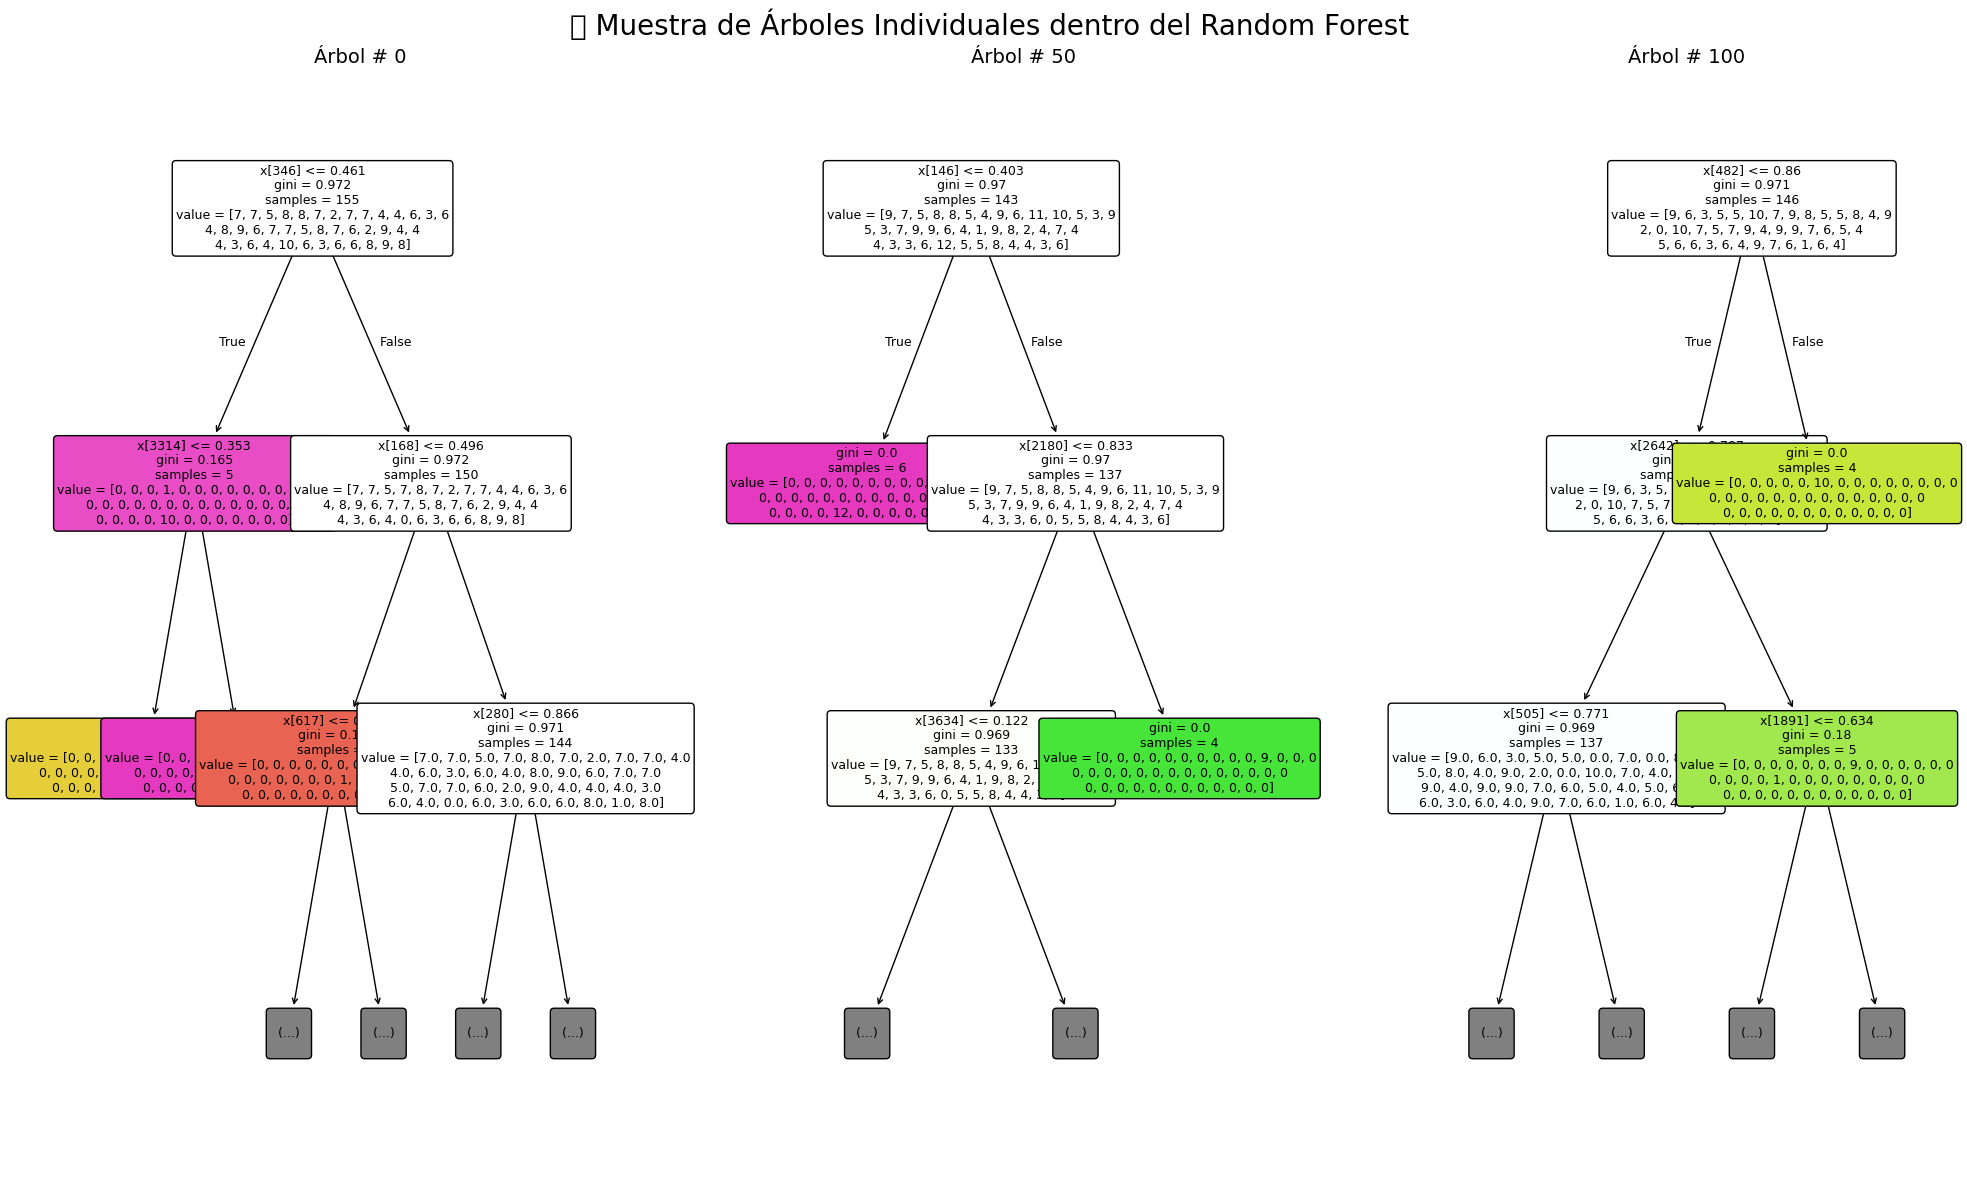

In [21]:
from sklearn.tree import plot_tree

# Vamos a visualizar 3 árboles diferentes del bosque (por ejemplo, el 0, el 50 y el 100)
arboles_a_ver = [0, 50, 100]

plt.figure(figsize=(20, 12))
plt.suptitle("🌲 Muestra de Árboles Individuales dentro del Random Forest", fontsize=20)

for i, idx_arbol in enumerate(arboles_a_ver):
    plt.subplot(1, 3, i + 1)
    # Extraemos el árbol específico del bosque
    arbol_individual = clf_rf.estimators_[idx_arbol]
    
    # Graficamos con profundidad limitada para que sea legible
    plot_tree(arbol_individual, 
              max_depth=2, 
              filled=True, 
              rounded=True, 
              fontsize=9)
    
    plt.title(f"Árbol # {idx_arbol}", fontsize=14)

plt.tight_layout()
plt.show()


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\4153781650.py:36: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


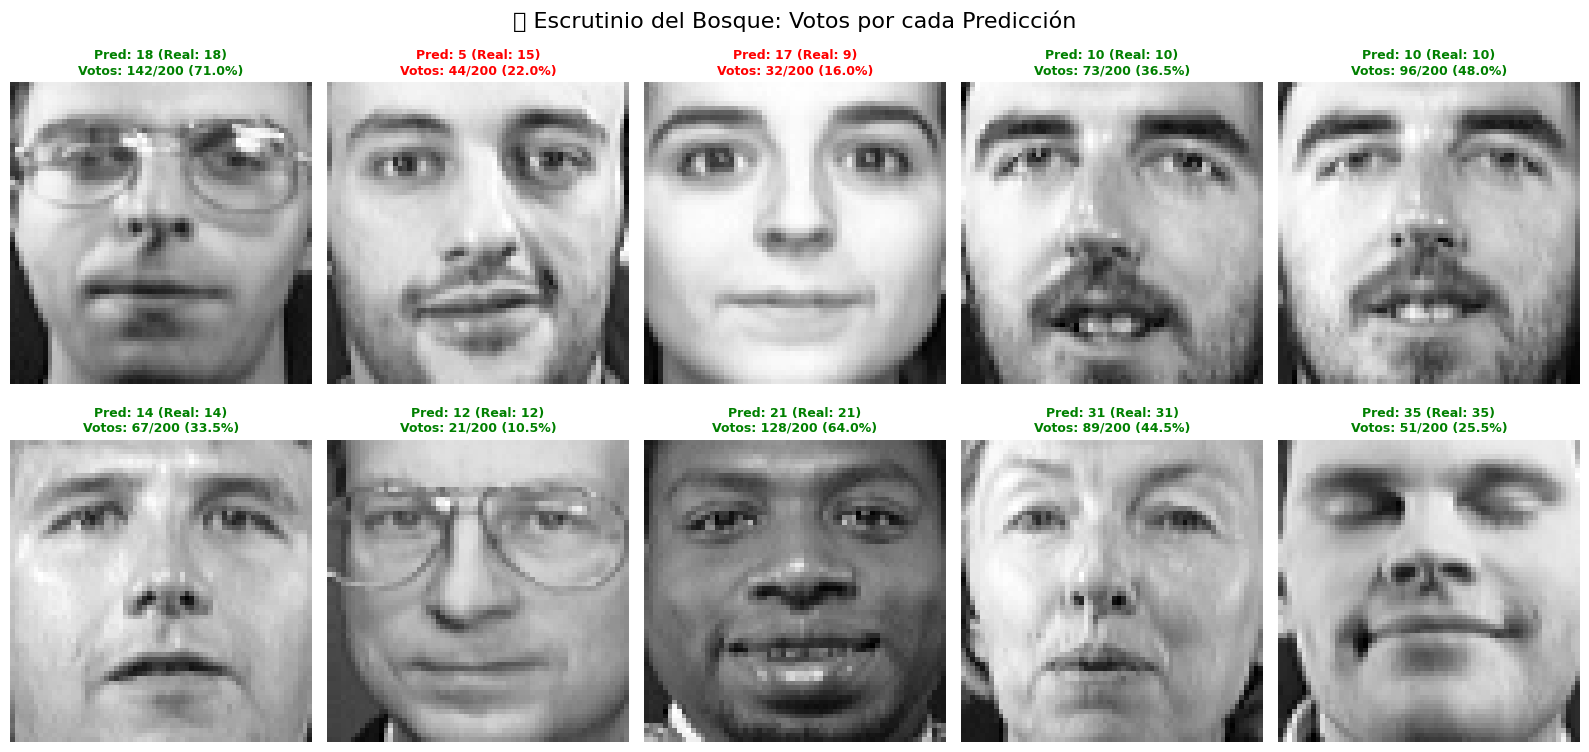

In [23]:
def visualizar_votacion_bosque(modelo, X_imagenes, y_reales, cantidad=10):
    # 1. Obtener la predicción final (voto mayoritario)
    pred_final = modelo.predict(X_imagenes)
    
    # 2. Obtener los votos de CADA uno de los árboles individuales
    # 'estimators_' contiene los 200 árboles. Creamos una matriz de votos.
    votos_todos_los_arboles = np.array([tree.predict(X_imagenes) for tree in modelo.estimators_])
    
    np.random.seed(42)
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    plt.figure(figsize=(16, 8))
    plt.suptitle("🗳️ Escrutinio del Bosque: Votos por cada Predicción", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        ganador = pred_final[idx]
        real = y_reales[idx]
        
        # Contar cuántos árboles votaron por el ganador
        conteo_votos = np.sum(votos_todos_los_arboles[:, idx] == ganador)
        total_arboles = len(modelo.estimators_)
        porcentaje = (conteo_votos / total_arboles) * 100
        
        color = 'green' if ganador == real else 'red'
        
        # Título con el escrutinio
        plt.title(f"Pred: {ganador} (Real: {real})\n"
                  f"Votos: {conteo_votos}/{total_arboles} ({porcentaje:.1f}%)", 
                  color=color, fontweight='bold', fontsize=9)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización de votos
visualizar_votacion_bosque(clf_rf, X_test, y_test, cantidad=10)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print("Entrenando Gradient Boosting Machine... (Esto puede tomar un par de minutos)")

# Configuración del modelo GBM con parámetros de regularización
clf_gbm = GradientBoostingClassifier(
    n_estimators=150,        # M: Número de iteraciones (cuántos árboles se sumarán)
    learning_rate=0.1,       # η: Tasa de aprendizaje (controla el aporte de cada nuevo árbol)
    max_depth=3,             # Árboles débiles (stumps/poca profundidad)
    subsample=0.8,           # Muestreo estocástico (usa el 80% de los datos en cada paso para evitar sobreajuste)
    random_state=semilla
)

# Entrenamiento secuencial (aditivo)
clf_gbm.fit(X_train, y_train)

# Evaluación en validación
y_pred_gbm_val = clf_gbm.predict(X_val)
acc_gbm_val = accuracy_score(y_val, y_pred_gbm_val)

print(f"\n✅ Accuracy de Gradient Boosting en VALIDACIÓN: {acc_gbm_val:.4f}")


Entrenando Gradient Boosting Machine... (Esto puede tomar un par de minutos)

✅ Accuracy de Gradient Boosting en VALIDACIÓN: 0.6625


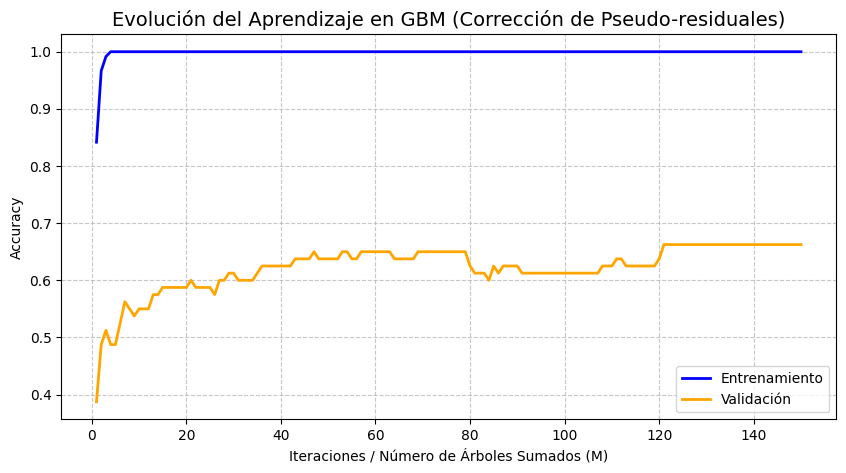

In [25]:
# Listas para almacenar el accuracy en cada paso
acc_train_staged = []
acc_val_staged = []

# staged_predict evalúa el modelo usando solo los primeros 'i' árboles
for y_pred_train_step in clf_gbm.staged_predict(X_train):
    acc_train_staged.append(accuracy_score(y_train, y_pred_train_step))

for y_pred_val_step in clf_gbm.staged_predict(X_val):
    acc_val_staged.append(accuracy_score(y_val, y_pred_val_step))

# Graficar la evolución
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(acc_train_staged) + 1), acc_train_staged, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(1, len(acc_val_staged) + 1), acc_val_staged, label='Validación', color='orange', linewidth=2)

plt.title("Evolución del Aprendizaje en GBM (Corrección de Pseudo-residuales)", fontsize=14)
plt.xlabel("Iteraciones / Número de Árboles Sumados (M)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [26]:
import pandas as pd

# Consolidamos todos los resultados del Taller 3 y 4
data_final = {
    "Modelo": [
        "Árbol de Decisión Único", 
        "Random Forest", 
        "Gradient Boosting (GBM)", 
        "MLP (Red Neuronal Profunda)"
    ],
    "Accuracy Validación": [acc_val, acc_rf_val, acc_gbm_val, acc_mlp], # Variables de celdas previas
    "Estrategia Principal": [
        "Reglas simples (Propenso a sobreajuste)", 
        "Reducción de Varianza (Votación Paralela)", 
        "Reducción de Sesgo (Corrección Secuencial)", 
        "Extracción Jerárquica de Características"
    ]
}

# Crear DataFrame y ordenarlo del mejor al peor
df_final = pd.DataFrame(data_final)
df_final = df_final.sort_values(by="Accuracy Validación", ascending=False).reset_index(drop=True)

print("🏆 TABLA COMPARATIVA DEFINITIVA DE MODELOS")
display(df_final.style.background_gradient(subset=["Accuracy Validación"], cmap="Greens"))


🏆 TABLA COMPARATIVA DEFINITIVA DE MODELOS


,Modelo,Accuracy Validación,Estrategia Principal
0,Random Forest,0.962500,Reducción de Varianza (Votación Paralela)
1,MLP (Red Neuronal Profunda),0.950000,Extracción Jerárquica de Características
2,Gradient Boosting (GBM),0.662500,Reducción de Sesgo (Corrección Secuencial)
3,Árbol de Decisión Único,0.500000,Reglas simples (Propenso a sobreajuste)


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\2713954093.py:27: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


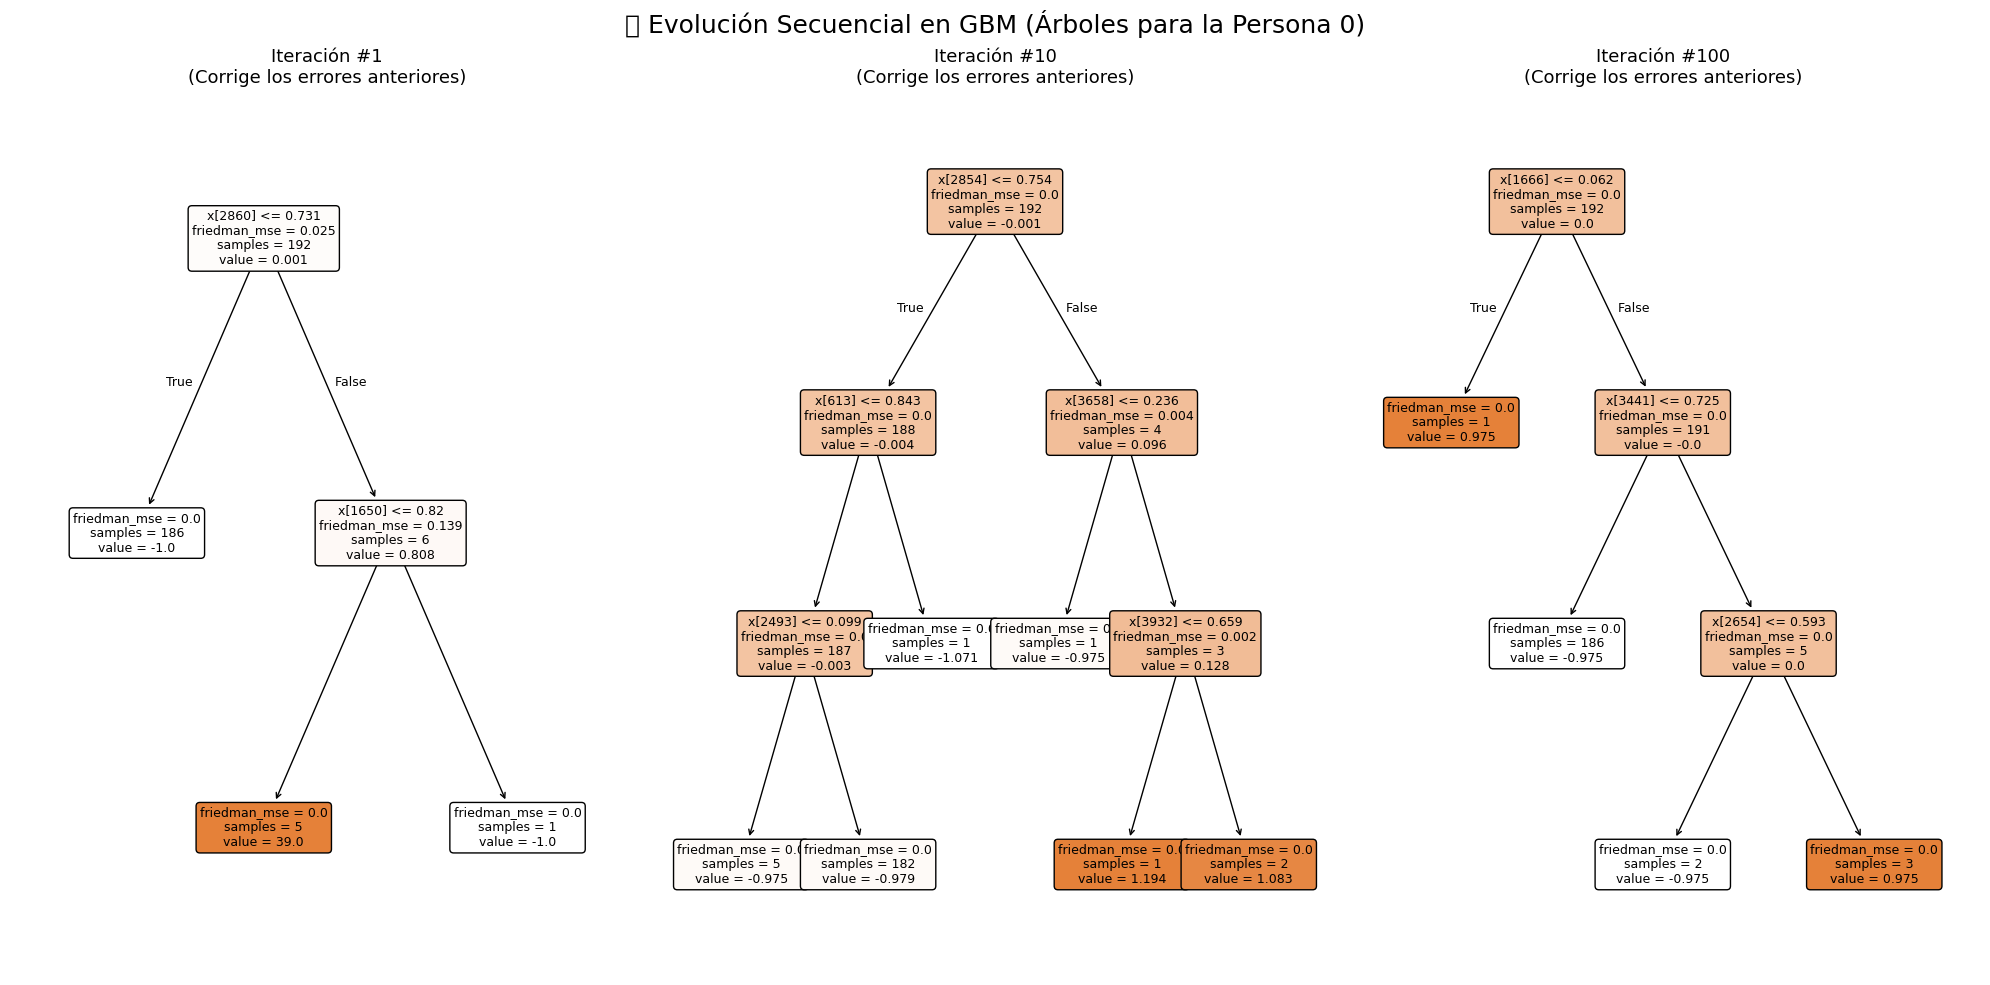

In [27]:
from sklearn.tree import plot_tree

# Seleccionamos una persona de ejemplo (Clase 0)
clase_objetivo = 0

# Seleccionamos 3 momentos en el tiempo (iteraciones)
iteraciones_a_ver = [0, 9, 99] 

plt.figure(figsize=(20, 10))
plt.suptitle(f"🚀 Evolución Secuencial en GBM (Árboles para la Persona {clase_objetivo})", fontsize=18)

for i, iteracion in enumerate(iteraciones_a_ver):
    plt.subplot(1, 3, i + 1)
    
    # Extraemos el árbol específico: [iteración, clase]
    arbol_secuencial = clf_gbm.estimators_[iteracion, clase_objetivo]
    
    # Graficamos (nota que los árboles en GBM suelen ser 'stumps' o muy bajitos)
    plot_tree(arbol_secuencial, 
              max_depth=3, 
              filled=True, 
              rounded=True, 
              fontsize=9)
    
    plt.title(f"Iteración #{iteracion + 1}\n(Corrige los errores anteriores)", fontsize=13)

plt.tight_layout()
plt.show()


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\3633729045.py:21: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


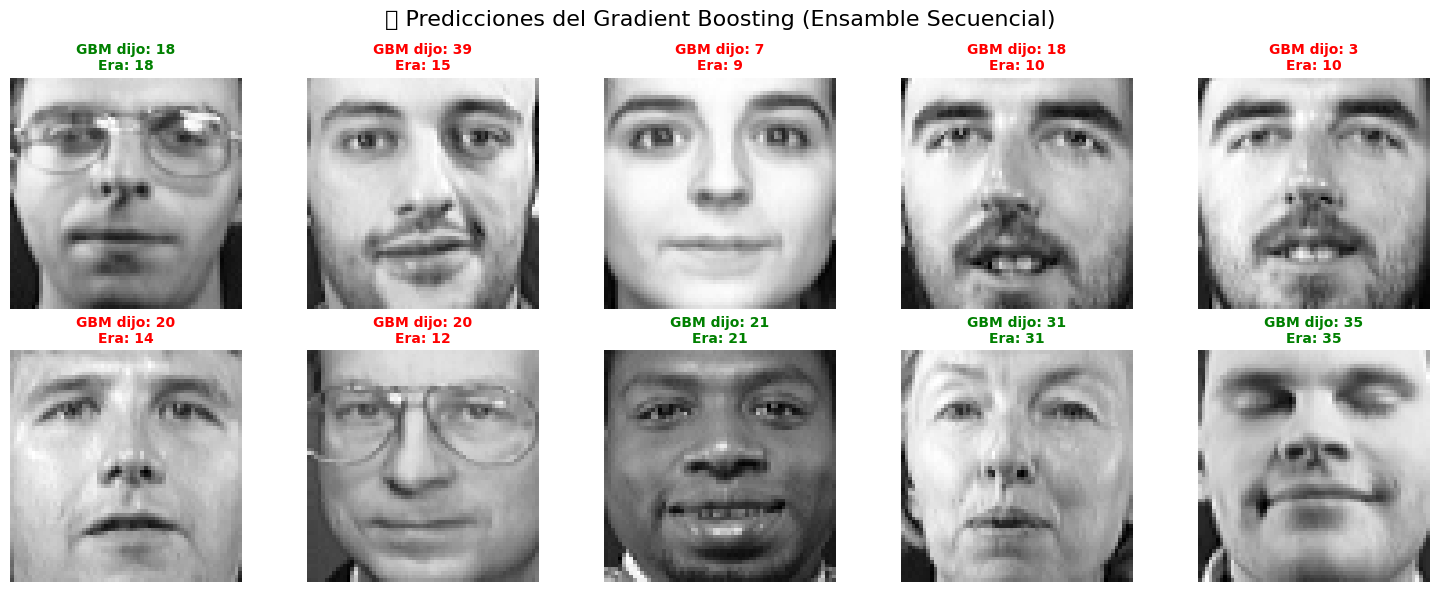

In [28]:
def visualizar_resultados_gbm(modelo, X_imagenes, y_reales, cantidad=10):
    predicciones = modelo.predict(X_imagenes)
    np.random.seed(42) # Usamos la misma semilla para que salgan las mismas caras a comparar
    indices = np.random.choice(len(y_reales), cantidad, replace=False)
    
    plt.figure(figsize=(15, 6))
    plt.suptitle("🚀 Predicciones del Gradient Boosting (Ensamble Secuencial)", fontsize=16)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        foto = X_imagenes[idx].reshape(64, 64)
        plt.imshow(foto, cmap='gray')
        plt.axis('off')
        
        pred = predicciones[idx]
        real = y_reales[idx]
        
        color = 'green' if pred == real else 'red'
        plt.title(f"GBM dijo: {pred}\nEra: {real}", color=color, fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Ejecutamos la visualización
visualizar_resultados_gbm(clf_gbm, X_test, y_test, cantidad=10)


Entrenando GBM Optimizado... (Paciencia, este aprendizaje lento es más preciso)

🚀 Accuracy del GBM OPTIMIZADO: 0.9375
Diferencia respecto al anterior: +0.2750


C:\Users\aiize\AppData\Local\Temp\ipykernel_27452\3633729045.py:21: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aiize\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


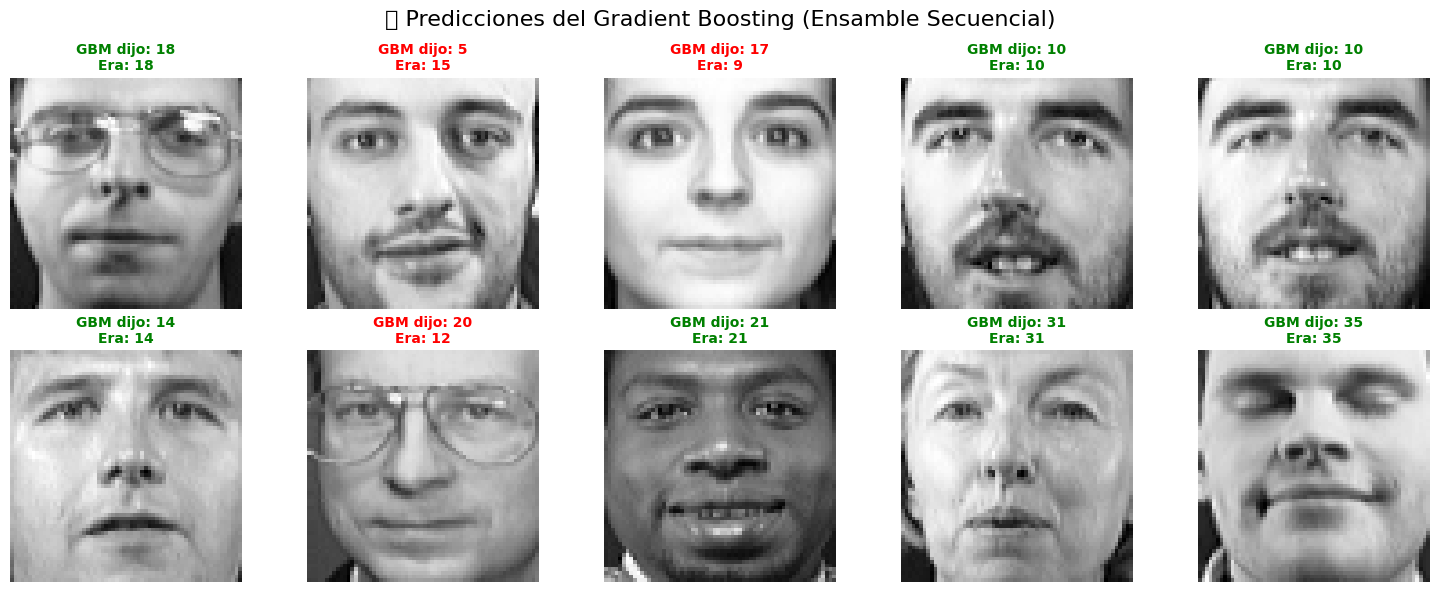

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

print("Entrenando GBM Optimizado... (Paciencia, este aprendizaje lento es más preciso)")

clf_gbm_opt = GradientBoostingClassifier(
    n_estimators=300,        # Más árboles para un aprendizaje más largo
    learning_rate=0.05,      # Aprendizaje más lento y cuidadoso (mitad del anterior)
    max_depth=3,             
    max_features='sqrt',     # ¡CLAVE! Cada árbol solo ve una parte aleatoria de los píxeles
    subsample=0.8,           
    min_samples_leaf=3,      # Evita que las hojas sean demasiado específicas de una sola foto
    random_state=semilla
)

clf_gbm_opt.fit(X_train, y_train)

# Nueva evaluación
y_pred_gbm_opt = clf_gbm_opt.predict(X_val)
acc_gbm_opt = accuracy_score(y_val, y_pred_gbm_opt)

print(f"\n🚀 Accuracy del GBM OPTIMIZADO: {acc_gbm_opt:.4f}")
print(f"Diferencia respecto al anterior: {acc_gbm_opt - acc_gbm_val:+.4f}")

# Actualizamos la visualización de resultados con el nuevo modelo
visualizar_resultados_gbm(clf_gbm_opt, X_test, y_test, cantidad=10)
